# Laboratorio 2: Clasificadores Multietiquetas

In [9]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

## Extraer datos y etiquetas

In [10]:
X, y = mnist.data, mnist.target
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


# Se divide el conjunto de datos
## Se usaran 60.000 elementos para entrenamiento
## Se usaran 10.000 elementos para prueba

In [11]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

## Convertimos las etiquetas de texto a números enteros

In [13]:
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

## Etiqueta 1: número par

In [14]:
y_train_par = (y_train_int % 2 == 0)
y_test_par = (y_test_int % 2 == 0)

## Etiqueta 2: Está en intervalo [5, 7]

In [15]:
y_train_rango = (y_train_int >= 5) & (y_train_int <= 7)
y_test_rango = (y_test_int >= 5) & (y_test_int <= 7)

## Multietiquetamos
### Importamos numpy para concatenar las dos columnas creando una matriz de dos dimensiones

In [16]:
import numpy as np

y_train_multi = np.c_[y_train_par, y_train_rango]
y_test_multi = np.c_[y_test_par, y_test_rango]

print(f"Forma de las etiquetas de entrenamiento: {y_train_multi.shape}")

Forma de las etiquetas de entrenamiento: (60000, 2)


# Entrenamiento y Evaluación de Clasificadores

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

## Definimos los 4 clasificadors
### Nota: la regresión logistica no soporta multietiqueta, por lo que la envolvemos en MultiOutputClassifier

In [18]:
from sklearn.model_selection import cross_val_predict

clasificadores_multi = {
    "KNeighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Regresión Logística": MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
}

resultados_roc_multi = {}

for nombre, clf in clasificadores_multi.items():
    print(f"--- Evaluando: {nombre} ---")
    
    y_pred = cross_val_predict(clf, X_train, y_train_multi, cv=3)
    
    try:
        probas = cross_val_predict(clf, X_train, y_train_multi, cv=3, method="predict_proba")
        if isinstance(probas, list):
            y_scores = np.column_stack([p[:, 1] for p in probas])
        else:
            # Random forest multietiqueta puede devolver un arreglo tridimensional
            y_scores = probas[:, :, 1] if len(probas.shape) == 3 else probas
    except Exception as e:
        print(f"No se pudo calcular predict_proba para {nombre}")
        continue

    p = precision_score(y_train_multi, y_pred, average='macro', zero_division=0)
    r = recall_score(y_train_multi, y_pred, average='macro')
    f1 = f1_score(y_train_multi, y_pred, average='macro')
    auc = roc_auc_score(y_train_multi, y_scores, average='macro')

    print(f"Precisión (Macro): {p:.4f}")
    print(f"Recall (Macro): {r:.4f}")
    print(f"F1 (Macro): {f1:.4f}")
    print(f"AUC (Macro): {auc:.4f}\n")

    fpr, tpr, _ = roc_curve(y_train_multi.ravel(), y_scores.ravel())
    resultados_roc_multi[nombre] = (fpr, tpr)


--- Evaluando: KNeighbors ---
Precisión (Macro): 0.9821
Recall (Macro): 0.9765
F1 (Macro): 0.9793
AUC (Macro): 0.9950

--- Evaluando: Random Forest ---
Precisión (Macro): 0.9834
Recall (Macro): 0.9585
F1 (Macro): 0.9706
AUC (Macro): 0.9978

--- Evaluando: Decision Tree ---
Precisión (Macro): 0.9210
Recall (Macro): 0.9213
F1 (Macro): 0.9211
AUC (Macro): 0.9356

--- Evaluando: Regresión Logística ---
Precisión (Macro): 0.8702
Recall (Macro): 0.8428
F1 (Macro): 0.8560
AUC (Macro): 0.9501



# Gráfica de la Curva ROC

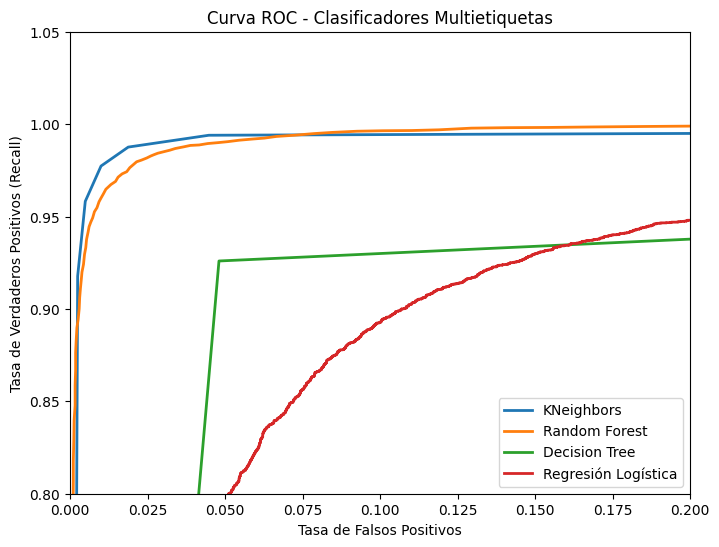

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for nombre, (fpr, tpr) in resultados_roc_multi.items():
    plt.plot(fpr, tpr, linewidth=2, label=nombre)

plt.axis([0, 0.2, 0.8, 1.05])

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Clasificadores Multietiquetas')
plt.legend(loc="lower right")
plt.show()